# Hands-On Machine Learning Course
## Module 6: Model Evaluation, Cross-Validation, Hyperparameter Tuning & Regularization

Welcome to Module 6 of the Hands-On Machine Learning Course! In this module, we explore the essential methodologies and tools for assessing, tuning, and diagnosing machine learning models.

Building a model and fitting it on data is only the first step. To ensure models perform reliably in real-world production settings, we must rigorously evaluate performance using task-appropriate metrics, employ cross-validation to prevent data leakage and split variance, optimize hyperparameters systematically, apply regularization to prevent overfitting, and analyze the bias-variance tradeoff.

---

### Table of Contents
1. **[Evaluation Metrics](#1.-Evaluation-Metrics)**
   - 1.1 Classification Confusion Matrix
   - 1.2 Core Metrics: Accuracy, Precision, Recall, and F1-Score
   - 1.3 Receiver Operating Characteristic (ROC) & ROC-AUC
   - 1.4 Precision-Recall (PR) Curve
   - 1.5 Scikit-Learn Classification Report
2. **[Cross-Validation Strategies](#2.-Cross-Validation-Strategies)**
   - 2.1 K-Fold Cross-Validation
   - 2.2 Stratified K-Fold Cross-Validation
   - 2.3 Leave-One-Out Cross-Validation (LOOCV)
3. **[Hyperparameter Tuning](#3.-Hyperparameter-Tuning)**
   - 3.1 Parameters vs. Hyperparameters
   - 3.2 Grid Search CV (`GridSearchCV`)
   - 3.3 Randomized Search CV (`RandomizedSearchCV`)
   - 3.4 Bayesian Optimization (`skopt.BayesSearchCV`)
4. **[Regularization Techniques](#4.-Regularization-Techniques)**
   - 4.1 Concept of Regularization
   - 4.2 L1 Regularization (Lasso) & Feature Selection
   - 4.3 L2 Regularization (Ridge)
   - 4.4 ElasticNet Regularization
   - 4.5 Impact of Regularization Strength ($\\alpha$) on Model Complexity & Coefficients
5. **[Overfitting, Underfitting & Bias-Variance Tradeoff](#5.-Overfitting,-Underfitting-&-Bias-Variance-Tradeoff)**
   - 5.1 High Bias vs. High Variance
   - 5.2 Learning Curves (Training Size vs. Performance)
   - 5.3 Empirical Bias-Variance Tradeoff Simulation
6. **[Summary & Model Tuning Best Practices](#6.-Summary-&-Model-Tuning-Best-Practices)**


## Environment Setup
Let's first import all required Python libraries for data processing, model training, evaluation, hyperparameter tuning, and visualization. We also configure Matplotlib styles for clean visualizations.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Datasets & Model Selection
from sklearn.datasets import load_breast_cancer, make_classification, make_regression
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut,
    cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV, learning_curve
)

# Scikit-Learn Metrics
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, auc, RocCurveDisplay,
    precision_recall_curve, PrecisionRecallDisplay, average_precision_score, mean_squared_error
)

# Models & Preprocessing
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Scikit-Optimize for Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Plotting Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titlesize'] = 16

print("All libraries imported successfully!")


All libraries imported successfully!


---
# 1. Evaluation Metrics

When evaluating machine learning classification models, relying solely on **Accuracy** can be misleading—especially on imbalanced datasets. Different real-world applications place varying costs on different types of prediction errors:

- **Type I Error (False Positive / FP)**: Predicting a positive result when the ground truth is negative (e.g., flagging a legitimate email as spam).
- **Type II Error (False Negative / FN)**: Predicting a negative result when the ground truth is positive (e.g., failing to diagnose a malignant tumor).

In this section, we study the **Confusion Matrix**, **Accuracy**, **Precision**, **Recall**, **F1-Score**, **ROC-AUC Curves**, **Precision-Recall Curves**, and the **Classification Report**.

### 1.1 Confusion Matrix

A **Confusion Matrix** is a $2 \times 2$ table (for binary classification) that summarizes prediction outcomes by comparing predicted labels against actual ground truth labels:

| | Predicted Negative (0) | Predicted Positive (1) |
|---|---|---|
| **Actual Negative (0)** | **True Negative (TN)** | **False Positive (FP)** (Type I Error) |
| **Actual Positive (1)** | **False Negative (FN)** (Type II Error) | **True Positive (TP)** |

Let's train a Logistic Regression model on the Breast Cancer dataset and construct a confusion matrix.

Confusion Matrix Values:
  True Negatives (TN):  41 (Malignant correctly classified)
  False Positives (FP): 1 (Malignant incorrectly predicted as Benign)
  False Negatives (FN): 1 (Benign incorrectly predicted as Malignant)
  True Positives (TP):  71 (Benign correctly classified)


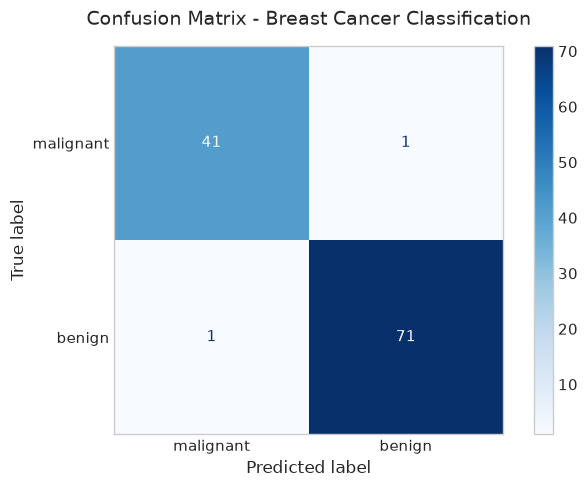

In [2]:
# Load Scikit-Learn Breast Cancer Dataset
cancer_data = load_breast_cancer()
X, y = cancer_data.data, cancer_data.target
feature_names = cancer_data.feature_names
target_names = cancer_data.target_names

# Split into Training (80%) and Test (20%) Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features and fit Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

# Predict test set
y_pred = clf.predict(X_test_scaled)
y_probs = clf.predict_proba(X_test_scaled)[:, 1]

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix Values:")
print(f"  True Negatives (TN):  {tn} (Malignant correctly classified)")
print(f"  False Positives (FP): {fp} (Malignant incorrectly predicted as Benign)")
print(f"  False Negatives (FN): {fn} (Benign incorrectly predicted as Malignant)")
print(f"  True Positives (TP):  {tp} (Benign correctly classified)")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Breast Cancer Classification', pad=15)
plt.grid(False)
plt.tight_layout()
plt.show()


### 1.2 Core Classification Metrics: Accuracy, Precision, Recall & F1-Score

Using the four components of the confusion matrix ($TP, TN, FP, FN$), we compute key evaluation metrics:

1. **Accuracy**: Proportion of total predictions that are correct.
   $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
   *When to use:* Balanced datasets where all misclassification costs are roughly equal.

2. **Precision**: Out of all instances predicted as positive, how many were actually positive?
   $$\text{Precision} = \frac{TP}{TP + FP}$$
   *When to use:* Minimizing False Positives is critical (e.g., spam detection, drug target discovery).

3. **Recall (Sensitivity / True Positive Rate)**: Out of all actual positive instances, how many did the model identify?
   $$\text{Recall} = \frac{TP}{TP + FN}$$
   *When to use:* Minimizing False Negatives is critical (e.g., medical diagnostics, credit card fraud detection).

4. **F1-Score**: The harmonic mean of Precision and Recall.
   $$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$
   *When to use:* Imbalanced datasets where both Precision and Recall need to be balanced.

In [3]:
# Calculate core evaluation metrics manually and via Scikit-Learn
acc_manual = (tp + tn) / (tp + tn + fp + fn)
prec_manual = tp / (tp + fp)
rec_manual = tp / (tp + fn)
f1_manual = 2 * (prec_manual * rec_manual) / (prec_manual + rec_manual)

acc_sklearn = accuracy_score(y_test, y_pred)
prec_sklearn = precision_score(y_test, y_pred)
rec_sklearn = recall_score(y_test, y_pred)
f1_sklearn = f1_score(y_test, y_pred)

# Summary DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Manual Calculation': [acc_manual, prec_manual, rec_manual, f1_manual],
    'Scikit-Learn Metric': [acc_sklearn, prec_sklearn, rec_sklearn, f1_sklearn]
})

print("=== Classification Metrics Comparison ===")
print(metrics_df.to_string(index=False))


=== Classification Metrics Comparison ===
   Metric  Manual Calculation  Scikit-Learn Metric
 Accuracy            0.982456             0.982456
Precision            0.986111             0.986111
   Recall            0.986111             0.986111
 F1-Score            0.986111             0.986111


### 1.3 Receiver Operating Characteristic (ROC) & ROC-AUC

The **ROC Curve** plots the **True Positive Rate (Recall)** against the **False Positive Rate (FPR)** across all possible probability threshold settings ($0.0 \to 1.0$):

$$\text{FPR} = \frac{FP}{FP + TN} = 1 - \text{Specificity}$$

- **Area Under Curve (ROC-AUC)** summarizes overall classification performance:
  - **$\text{AUC} = 0.5$**: Random guessing (no discriminative ability).
  - **$\text{AUC} = 1.0$**: Perfect classifier.
  - **$\text{AUC} > 0.8$**: Strong classification performance.

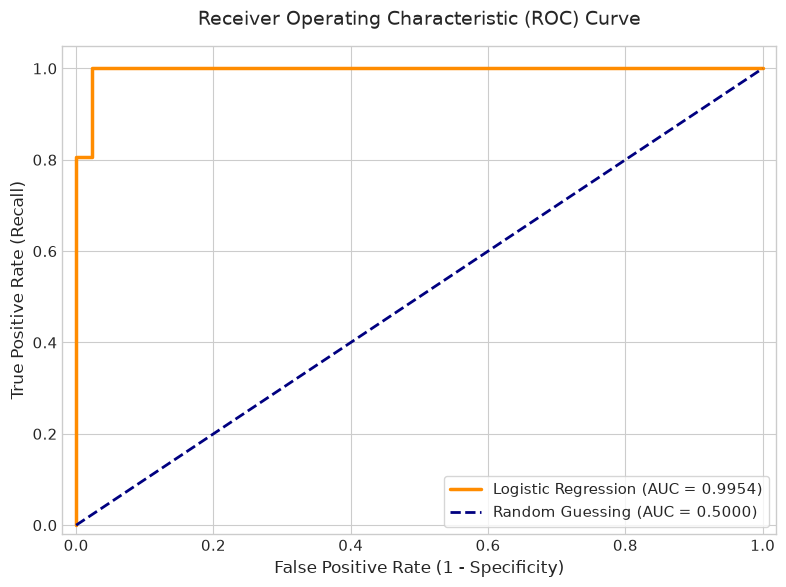

In [4]:
# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5000)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve', pad=15)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()


### 1.4 Precision-Recall Curve

While ROC curves are widely used, on **severely imbalanced datasets** (where the negative class vastly outnumbers the positive class), the False Positive Rate stays small because $TN$ is huge. Consequently, ROC curves can paint an overly optimistic picture.

The **Precision-Recall (PR) Curve** plots Precision vs. Recall across all thresholds. It focuses directly on the minority positive class without being inflated by $TN$.

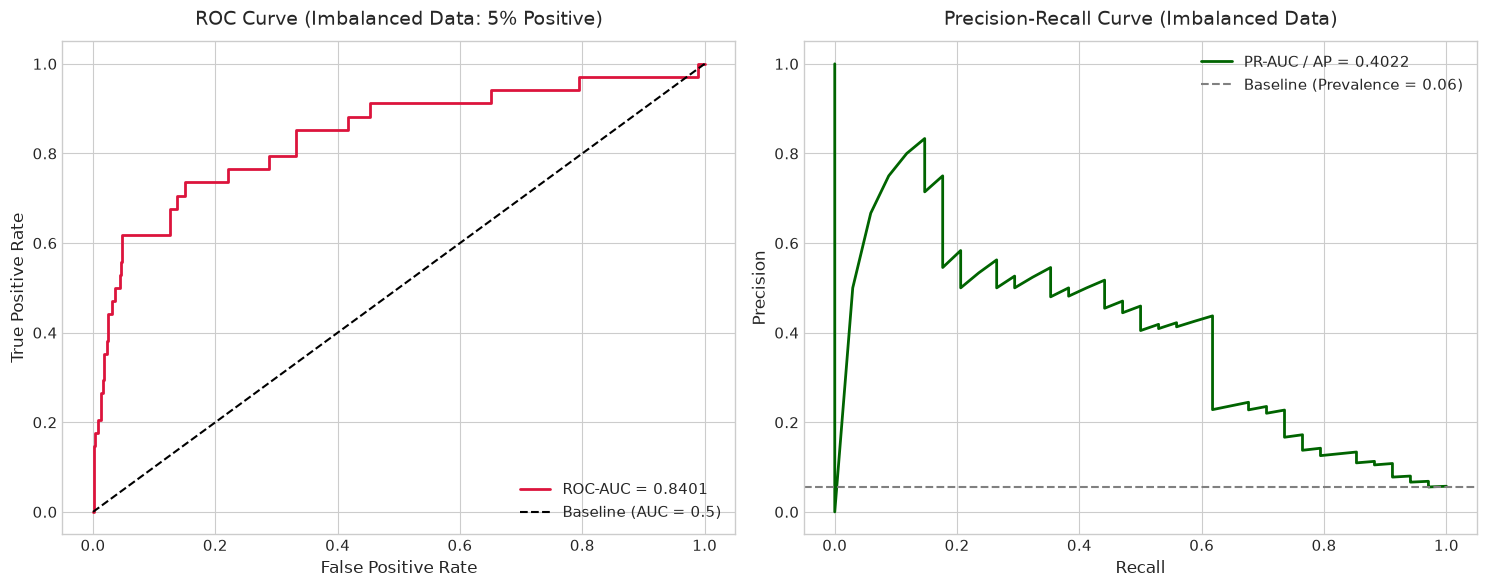

In [5]:
# Create a synthetic imbalanced dataset (95% negative, 5% positive)
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, n_informative=10,
    weights=[0.95, 0.05], random_state=42
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

# Train Logistic Regression
model_imb = LogisticRegression(random_state=42)
model_imb.fit(X_train_imb, y_train_imb)
y_probs_imb = model_imb.predict_proba(X_test_imb)[:, 1]

# Precision-Recall Curve & Average Precision Score
precision_vals, recall_vals, _ = precision_recall_curve(y_test_imb, y_probs_imb)
ap_score = average_precision_score(y_test_imb, y_probs_imb)
baseline_pr = y_test_imb.sum() / len(y_test_imb)

# Plot ROC vs PR Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
fpr_imb, tpr_imb, _ = roc_curve(y_test_imb, y_probs_imb)
roc_auc_imb = auc(fpr_imb, tpr_imb)
axes[0].plot(fpr_imb, tpr_imb, color='crimson', lw=2, label=f'ROC-AUC = {roc_auc_imb:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.5)')
axes[0].set_title('ROC Curve (Imbalanced Data: 5% Positive)', pad=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# PR Curve
axes[1].plot(recall_vals, precision_vals, color='darkgreen', lw=2, label=f'PR-AUC / AP = {ap_score:.4f}')
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--', label=f'Baseline (Prevalence = {baseline_pr:.2f})')
axes[1].set_title('Precision-Recall Curve (Imbalanced Data)', pad=12)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


### 1.5 Scikit-Learn Classification Report

The `classification_report` utility aggregates key metrics per class, along with overall averages:

- **Macro Average**: Unweighted average of precision, recall, and F1-score across classes (treats all classes equally).
- **Weighted Average**: Average weighted by the number of true instances (**Support**) in each class.
- **Support**: Number of actual occurrences of each class in the dataset.

In [6]:
# Generate classification report for the Breast Cancer model
report = classification_report(y_test, y_pred, target_names=target_names)
print("=== Classification Report ===")
print(report)


=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
# 2. Cross-Validation Strategies

A single train-test split evaluates a model on one fixed partition of data. Depending on random seed selection, the split might randomly contain easy or hard samples, leading to **high variance in evaluation results**.

**Cross-Validation (CV)** solves this by partitioning the dataset multiple times, training and validating across different folds to produce a robust estimate of generalization performance.

In this section, we cover:
1. **K-Fold Cross-Validation**
2. **Stratified K-Fold Cross-Validation**
3. **Leave-One-Out Cross-Validation (LOOCV)**

### 2.1 K-Fold Cross-Validation

In **K-Fold CV**, the dataset is divided into $K$ equal-sized folds:
1. Model trains on $K-1$ folds and validates on the remaining $1$ fold.
2. Step 1 repeats $K$ times, holding out a different fold each time.
3. The final performance metric is the average across all $K$ iterations.

```
Iteration 1: [ Test  | Train | Train | Train | Train ]
Iteration 2: [ Train |  Test | Train | Train | Train ]
Iteration 3: [ Train | Train |  Test | Train | Train ]
Iteration 4: [ Train | Train | Train |  Test | Train ]
Iteration 5: [ Train | Train | Train | Train |  Test ]
```

In [7]:
# Prepare dataset & pipeline
X_cancer, y_cancer = load_breast_cancer(return_X_y=True)
pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))

# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_cancer, y_cancer, cv=kf, scoring='accuracy')

print(f"5-Fold CV Accuracy Scores per Fold: {np.round(scores, 4)}")
print(f"Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Using cross_validate to retrieve detailed timing & scoring metrics
cv_results = cross_validate(pipeline, X_cancer, y_cancer, cv=kf, scoring=['accuracy', 'precision', 'recall', 'f1'])
cv_df = pd.DataFrame(cv_results)
print("\n=== Detailed Cross-Validation Results ===")
print(cv_df[['test_accuracy', 'test_precision', 'test_recall', 'test_f1']].mean().to_frame(name='Mean Score'))


5-Fold CV Accuracy Scores per Fold: [0.9737 0.9825 0.9649 0.9912 0.9735]
Mean Accuracy: 0.9771 (+/- 0.0090)

=== Detailed Cross-Validation Results ===
                Mean Score
test_accuracy     0.977146
test_precision    0.977565
test_recall       0.986186
test_f1           0.981774


### 2.2 Stratified K-Fold Cross-Validation

Standard K-Fold randomly splits data into folds. For **imbalanced datasets**, standard random splitting can produce folds with unequal class distributions—or even folds containing zero samples of the minority class!

**Stratified K-Fold** guarantees that every fold contains approximately the same percentage of samples for each target class as the complete dataset.

In [8]:
# Demonstrate Stratified K-Fold vs K-Fold on imbalanced data (90:10 ratio)
X_imb_cv, y_imb_cv = make_classification(
    n_samples=500, n_features=10, weights=[0.90, 0.10], random_state=42
)

n_splits = 5
kf_standard = KFold(n_splits=n_splits, shuffle=True, random_state=42)
skf_stratified = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print("=== Fold Class Distribution Comparison ===")
print(f"Overall Class 1 Ratio in Dataset: {np.mean(y_imb_cv):.2%}\n")

print("Standard K-Fold Class 1 Percentages:")
for i, (_, val_idx) in enumerate(kf_standard.split(X_imb_cv, y_imb_cv)):
    ratio = np.mean(y_imb_cv[val_idx])
    print(f"  Fold {i+1}: {ratio:.2%}")

print("\nStratified K-Fold Class 1 Percentages:")
for i, (_, val_idx) in enumerate(skf_stratified.split(X_imb_cv, y_imb_cv)):
    ratio = np.mean(y_imb_cv[val_idx])
    print(f"  Fold {i+1}: {ratio:.2%}")


=== Fold Class Distribution Comparison ===
Overall Class 1 Ratio in Dataset: 10.40%

Standard K-Fold Class 1 Percentages:
  Fold 1: 10.00%
  Fold 2: 8.00%
  Fold 3: 6.00%
  Fold 4: 10.00%
  Fold 5: 18.00%

Stratified K-Fold Class 1 Percentages:
  Fold 1: 11.00%
  Fold 2: 11.00%
  Fold 3: 10.00%
  Fold 4: 10.00%
  Fold 5: 10.00%


### 2.3 Leave-One-Out Cross-Validation (LOOCV)

**Leave-One-Out Cross-Validation (LOOCV)** is an extreme variant of $K$-Fold where $K = N$ ($N$ is total dataset size):
- For $N$ samples, $N$ models are trained.
- Each model trains on $N-1$ samples and evaluates on the single held-out sample.

**Tradeoffs:**
- **Pros:** Completely deterministic (no random split variance); uses maximum available training data per fold ($N-1$).
- **Cons:** Extremely computationally expensive for large datasets ($N$ total fits); validation error estimator has high variance because training sets overlap heavily across iterations.

In [9]:
# Demonstrate LOOCV on a subset of dataset (e.g. 50 samples)
X_sub, y_sub = X_cancer[:50], y_cancer[:50]

loocv = LeaveOneOut()
loocv_scores = cross_val_score(pipeline, X_sub, y_sub, cv=loocv, scoring='accuracy')

print(f"LOOCV Total Iterations (N): {len(loocv_scores)}")
print(f"LOOCV Mean Accuracy: {loocv_scores.mean():.4f}")
print(f"LOOCV Standard Deviation: {loocv_scores.std():.4f}")


LOOCV Total Iterations (N): 50
LOOCV Mean Accuracy: 0.9600
LOOCV Standard Deviation: 0.1960


---
# 3. Hyperparameter Tuning

Machine learning algorithms involve two types of variables:
- **Parameters**: Learned directly from training data during optimization (e.g., weights $w$ and bias $b$ in regression, split thresholds in decision trees).
- **Hyperparameters**: Structural settings configured **prior to training** that govern learning capacity and model architecture (e.g., regularization parameter $C$, tree `max_depth`, number of trees `n_estimators`).

Finding optimal hyperparameter configurations is crucial for maximizing model performance. In this section, we cover three search strategies:
1. **Grid Search (`GridSearchCV`)**
2. **Randomized Search (`RandomizedSearchCV`)**
3. **Bayesian Optimization (`skopt.BayesSearchCV`)**

### 3.1 Grid Search CV (`GridSearchCV`)

**GridSearchCV** performs an exhaustive search over a user-specified grid of hyperparameter values, evaluating every possible combination via cross-validation.

- **Total fits required**: $\prod |H_i| \times K$ folds.
- **Best for:** Small parameter spaces where exploring every combination is computationally feasible.

GridSearchCV Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 50}
GridSearchCV Best CV Accuracy: 0.9670
Test Set Accuracy with Best Params: 0.9561


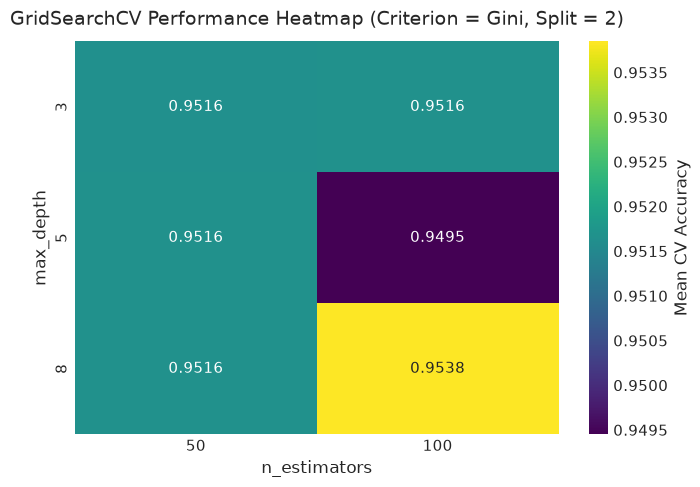

In [10]:
# Define hyperparameter grid for Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"GridSearchCV Best Parameters: {grid_search.best_params_}")
print(f"GridSearchCV Best CV Accuracy: {grid_search.best_score_:.4f}")
print(f"Test Set Accuracy with Best Params: {grid_search.score(X_test, y_test):.4f}")

# Visualize Grid Search Results as Heatmap (for max_depth vs n_estimators under gini criterion & min_samples_split=2)
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_df = results_df[
    (results_df['param_criterion'] == 'gini') & (results_df['param_min_samples_split'] == 2)
].pivot(
    index='param_max_depth', columns='param_n_estimators', values='mean_test_score'
)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_df, annot=True, fmt='.4f', cmap='viridis', cbar_kws={'label': 'Mean CV Accuracy'})
plt.title('GridSearchCV Performance Heatmap (Criterion = Gini, Split = 2)', pad=12)
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()


### 3.2 Randomized Search CV (`RandomizedSearchCV`)

Unlike exhaustive Grid Search, **RandomizedSearchCV** randomly samples a fixed number of parameter combinations (`n_iter`) from specified probability distributions or discrete options.

- **Advantages:** Explores high-dimensional parameter spaces efficiently; fixes total computational cost by capping `n_iter`.
- **Empirical Principle:** Important hyperparameters vary widely across datasets; randomly sampling parameter space finds good solutions much faster than grid sampling.

In [11]:
from scipy.stats import randint, uniform

# Define continuous/discrete parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(20, 200),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 10),
    'max_features': uniform(0.2, 0.8)
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"RandomizedSearchCV Completed in {elapsed_time:.2f} seconds")
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Score: {random_search.best_score_:.4f}")


RandomizedSearchCV Completed in 9.07 seconds
Best Parameters: {'max_depth': 14, 'max_features': 0.31273937997981016, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 90}
Best Cross-Validation Score: 0.9626


### 3.3 Bayesian Optimization (`skopt.BayesSearchCV`)

Both Grid Search and Random Search evaluate hyperparameter combinations **independently**, ignoring information from past trials.

**Bayesian Optimization** builds a probabilistic surrogate model (typically a **Gaussian Process**) of the objective function ($f(\theta) = \text{CV\_Score}$). It uses an **Acquisition Function** (e.g., Expected Improvement / EI) to intelligently select the next parameter setting to sample:
1. **Exploitation:** Sampling near parameter settings that produced high scores previously.
2. **Exploration:** Sampling in parameter regions with high predictive uncertainty.

This enables Bayesian Optimization to locate global optima in far fewer iterations.

BayesSearchCV Completed in 9.71 seconds
Best Parameters: OrderedDict([('criterion', 'entropy'), ('max_depth', 20), ('min_samples_leaf', 1), ('min_samples_split', 6), ('n_estimators', 24)])
Best CV Accuracy: 0.9670


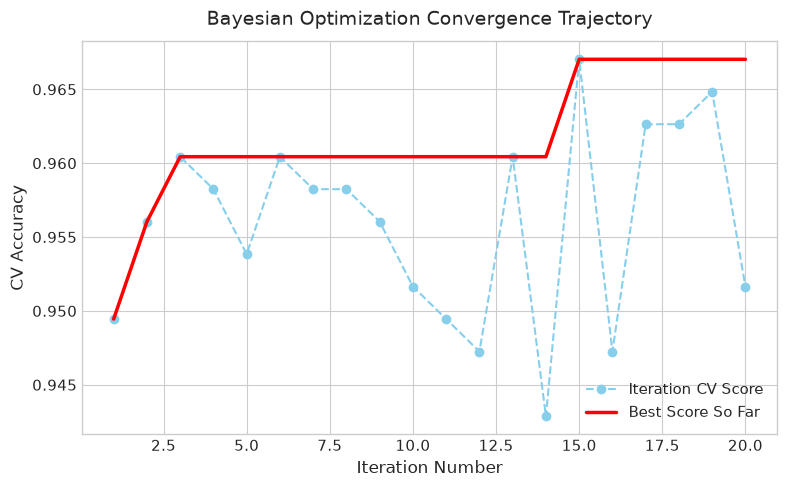

In [12]:
# Define Search Space using skopt types
search_space = {
    'n_estimators': Integer(20, 200),
    'max_depth': Integer(2, 20),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 10),
    'criterion': Categorical(['gini', 'entropy'])
}

bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces=search_space,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
bayes_search.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"BayesSearchCV Completed in {elapsed_time:.2f} seconds")
print(f"Best Parameters: {bayes_search.best_params_}")
print(f"Best CV Accuracy: {bayes_search.best_score_:.4f}")

# Plot Bayesian Optimization score convergence trajectory over iterations
scores_over_time = bayes_search.cv_results_['mean_test_score']
best_cumulative_scores = np.maximum.accumulate(scores_over_time)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(scores_over_time) + 1), scores_over_time, 'o--', color='skyblue', label='Iteration CV Score')
plt.plot(range(1, len(scores_over_time) + 1), best_cumulative_scores, 'r-', lw=2.5, label='Best Score So Far')
plt.title('Bayesian Optimization Convergence Trajectory', pad=12)
plt.xlabel('Iteration Number')
plt.ylabel('CV Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
# 4. Regularization Techniques

Overfitting occurs when a machine learning model fits training noise rather than true underlying patterns, leading to large coefficient values and high test error.

**Regularization** adds a penalty term to the model's loss function to constrain model complexity and shrink coefficient magnitudes:

$$\text{Objective} = \text{Loss}(y, \hat{y}) + \alpha \cdot \text{Penalty}(w)$$

Where $\alpha \ge 0$ is the regularization strength hyperparameter.

In this section, we cover:
1. **L1 Regularization (Lasso)**
2. **L2 Regularization (Ridge)**
3. **ElasticNet Regularization**
4. **Effect of Regularization Strength on Model Complexity & Coefficients**

### 4.1 L1 Regularization (Lasso) & Feature Selection

**L1 Regularization (Lasso - Least Absolute Shrinkage and Selection Operator)** penalizes the sum of absolute values of model weights:

$$\text{Loss}_{L1} = \frac{1}{2N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |w_j|$$

**Key Characteristic:**
Because the L1 penalty function forms a diamond constraint region with sharp corners at coordinate axes in parameter space, optimization solutions frequently occur at parameter values where coefficients are **driven strictly to zero ($w_j = 0$)**.

Thus, Lasso performs **automatic feature selection**, producing sparse models.

In [13]:
# Generate regression dataset with correlated & noisy features
X_reg, y_reg = make_regression(
    n_samples=200, n_features=20, n_informative=5, noise=15.0, random_state=42
)

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

# Fit Lasso with alpha = 0.5
lasso = Lasso(alpha=0.5, random_state=42)
lasso.fit(X_reg_scaled, y_reg)

# Count non-zero coefficients
non_zero_feats = np.sum(lasso.coef_ != 0)
total_feats = X_reg.shape[1]

print(f"Lasso (alpha=0.5): Retained {non_zero_feats} / {total_feats} features (Sparsity: {total_feats - non_zero_feats} features zeroed out)")


Lasso (alpha=0.5): Retained 15 / 20 features (Sparsity: 5 features zeroed out)


### 4.2 L2 Regularization (Ridge)

**L2 Regularization (Ridge Regression)** penalizes the sum of squared model weights:

$$\text{Loss}_{L2} = \frac{1}{2N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p w_j^2$$

**Key Characteristic:**
The L2 penalty forms a spherical constraint region. It shrinks coefficients smoothly toward zero but **never forces them strictly to zero**. Ridge is particularly effective when features exhibit high **multicollinearity**.

In [14]:
# Fit Ridge with alpha = 10.0
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_reg_scaled, y_reg)

# Compare coefficient magnitudes between Lasso and Ridge
coef_comparison = pd.DataFrame({
    'Feature Index': [f'Feature {i}' for i in range(total_feats)],
    'Lasso Coef (L1)': np.round(lasso.coef_, 3),
    'Ridge Coef (L2)': np.round(ridge.coef_, 3)
})

print("=== Lasso vs Ridge Coefficient Comparison (First 10 features) ===")
print(coef_comparison.head(10).to_string(index=False))


=== Lasso vs Ridge Coefficient Comparison (First 10 features) ===
Feature Index  Lasso Coef (L1)  Ridge Coef (L2)
    Feature 0            0.979            2.557
    Feature 1            1.151            1.961
    Feature 2           -0.000           -0.479
    Feature 3            0.229            0.416
    Feature 4           48.100           46.238
    Feature 5           -0.633           -0.995
    Feature 6            0.000            0.536
    Feature 7           51.567           49.364
    Feature 8           61.239           59.074
    Feature 9           -0.254           -0.286


### 4.3 ElasticNet Regularization

**ElasticNet** combines both L1 and L2 penalties using a mixing hyperparameter $\ell_1\text{\_ratio} \in [0, 1]$:

$$\text{Loss}_{\text{ElasticNet}} = \frac{1}{2N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 + \alpha \cdot \ell_1\text{\_ratio} \sum_{j=1}^p |w_j| + \frac{\alpha(1 - \ell_1\text{\_ratio})}{2} \sum_{j=1}^p w_j^2$$

- **$\ell_1\text{\_ratio} = 1$**: Equivalent to Lasso.
- **$\ell_1\text{\_ratio} = 0$**: Equivalent to Ridge.
- **$0 < \ell_1\text{\_ratio} < 1$**: Combines feature selection of Lasso with group selection stability of Ridge.

In [15]:
# Tune ElasticNet using ElasticNetCV
l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99]
alphas = np.logspace(-3, 2, 50)

elastic_cv = ElasticNetCV(l1_ratio=l1_ratios, alphas=alphas, cv=5, random_state=42)
elastic_cv.fit(X_reg_scaled, y_reg)

print(f"Optimal Alpha selected by ElasticNetCV: {elastic_cv.alpha_:.4f}")
print(f"Optimal l1_ratio selected by ElasticNetCV: {elastic_cv.l1_ratio_:.2f}")


Optimal Alpha selected by ElasticNetCV: 0.4498
Optimal l1_ratio selected by ElasticNetCV: 0.99


### 4.4 Regularization Paths: Coefficient Shrinkage vs $\alpha$

Let's visualize how increasing regularization strength $\alpha$ alters feature coefficient values for both Lasso and Ridge.

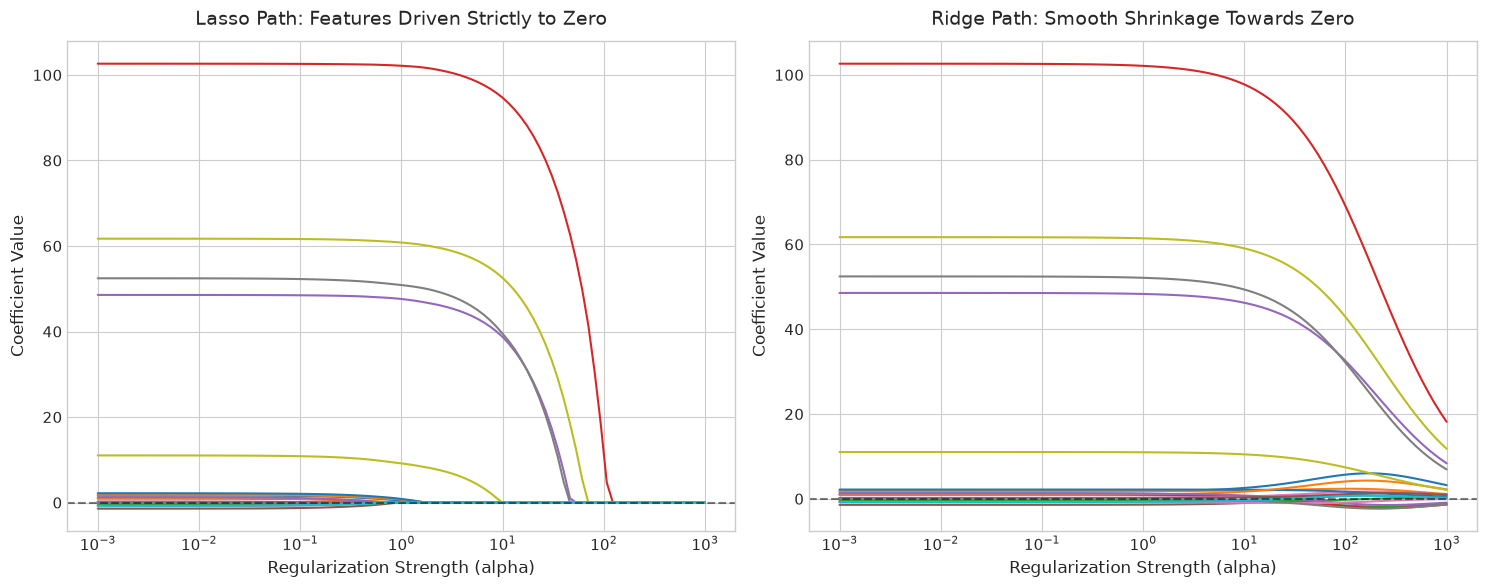

In [16]:
alphas_path = np.logspace(-3, 3, 100)

lasso_coefs = []
ridge_coefs = []

for a in alphas_path:
    l_model = Lasso(alpha=a, random_state=42, max_iter=5000)
    l_model.fit(X_reg_scaled, y_reg)
    lasso_coefs.append(l_model.coef_)

    r_model = Ridge(alpha=a, random_state=42)
    r_model.fit(X_reg_scaled, y_reg)
    ridge_coefs.append(r_model.coef_)

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)

# Plot Regularization Paths
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Lasso Path
for i in range(total_feats):
    axes[0].plot(alphas_path, lasso_coefs[:, i], label=f'Feat {i}' if i < 5 else "")
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularization Strength (alpha)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Lasso Path: Features Driven Strictly to Zero', pad=12)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)

# Ridge Path
for i in range(total_feats):
    axes[1].plot(alphas_path, ridge_coefs[:, i], label=f'Feat {i}' if i < 5 else "")
axes[1].set_xscale('log')
axes[1].set_xlabel('Regularization Strength (alpha)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Ridge Path: Smooth Shrinkage Towards Zero', pad=12)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
# 5. Overfitting, Underfitting & Bias-Variance Tradeoff

In supervised learning, model error can be decomposed into three fundamental components:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

1. **High Bias (Underfitting)**: The model is overly simple and fails to capture complex relationships in data.
   - *Signature:* High training error **and** high validation error.
2. **High Variance (Overfitting)**: The model is overly complex and memorizes noise in training data.
   - *Signature:* Low training error, but high validation error (large train-validation gap).
3. **Irreducible Error**: Inherent noise in the problem domain that cannot be eliminated by any model.

In this section, we study **Learning Curves** and conduct a **Bias-Variance Simulation**.

### 5.1 Learning Curves

**Learning Curves** plot model performance (training and validation scores) as a function of training dataset size ($N$).

- **Underfitting Model**: Training and validation scores converge quickly to a low/poor score. Adding more training data **will not help**.
- **Overfitting Model**: High training score with a large gap to validation score. Adding more training data **helps narrow the gap**.

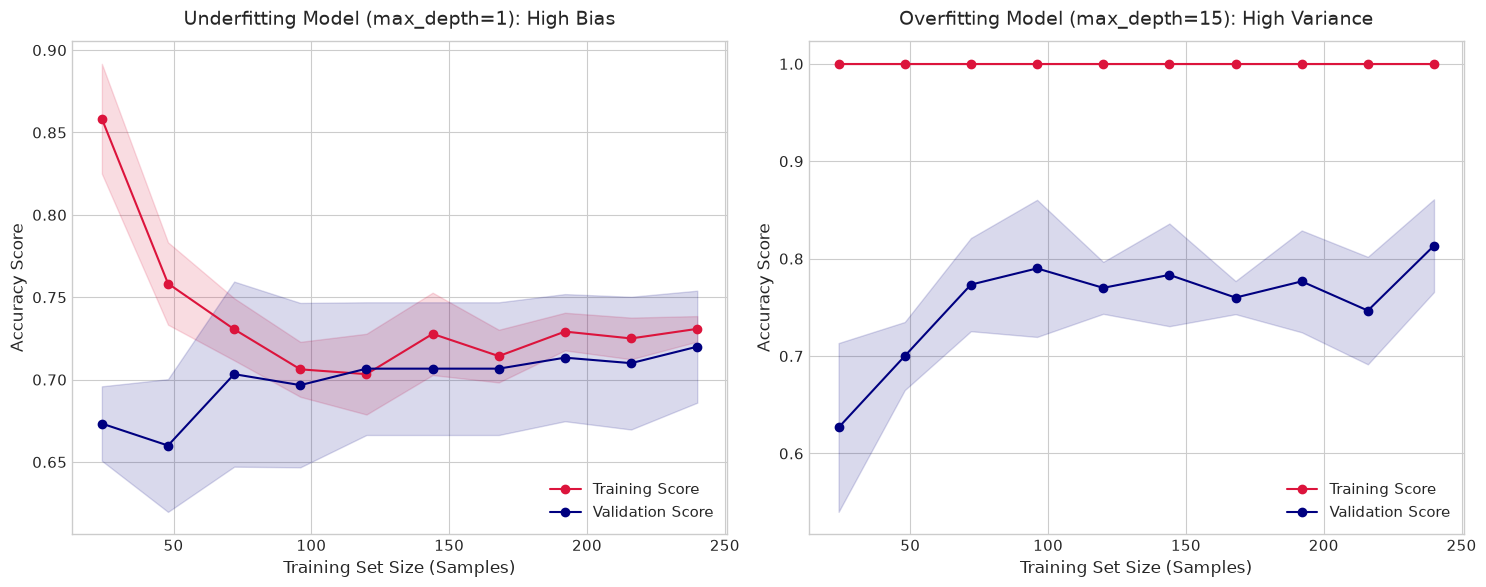

In [17]:
# Generate Synthetic Regression Data
X_lc, y_lc = make_regression(n_samples=300, n_features=15, noise=20.0, random_state=42)

# Define Underfitting (High Bias) and Overfitting (High Variance) models
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=42)
overfit_model = DecisionTreeClassifier(max_depth=15, min_samples_split=2, random_state=42)

# Classification dataset for Decision Trees
X_lc_cls, y_lc_cls = make_classification(n_samples=300, n_features=15, n_informative=5, random_state=42)

train_sizes = np.linspace(0.1, 1.0, 10)

def plot_learning_curve_demo(model, X, y, title, ax):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X, y, train_sizes=train_sizes, cv=5, scoring='accuracy', n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax.plot(train_sizes_abs, train_mean, 'o-', color='crimson', label='Training Score')
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='crimson')
    ax.plot(train_sizes_abs, val_mean, 'o-', color='navy', label='Validation Score')
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='navy')

    ax.set_title(title, pad=12)
    ax.set_xlabel('Training Set Size (Samples)')
    ax.set_ylabel('Accuracy Score')
    ax.legend(loc='lower right')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_learning_curve_demo(underfit_model, X_lc_cls, y_lc_cls, 'Underfitting Model (max_depth=1): High Bias', axes[0])
plot_learning_curve_demo(overfit_model, X_lc_cls, y_lc_cls, 'Overfitting Model (max_depth=15): High Variance', axes[1])

plt.tight_layout()
plt.show()


### 5.2 Bias-Variance Tradeoff Empirical Simulation

To demonstrate the Bias-Variance tradeoff empirically, we fit polynomial regression models of increasing degrees ($d = 1, 2, \dots, 12$) to data generated from a non-linear sine wave function:

$$y = \sin(1.5 \pi x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.2^2)$$

- **Degree 1 (Linear)**: Too simple $\implies$ High Bias (Underfitting).
- **Degree 3-4 (Optimal)**: Balanced model complexity.
- **Degree 12 (High Polynomial)**: Highly complex $\implies$ High Variance (Overfitting).

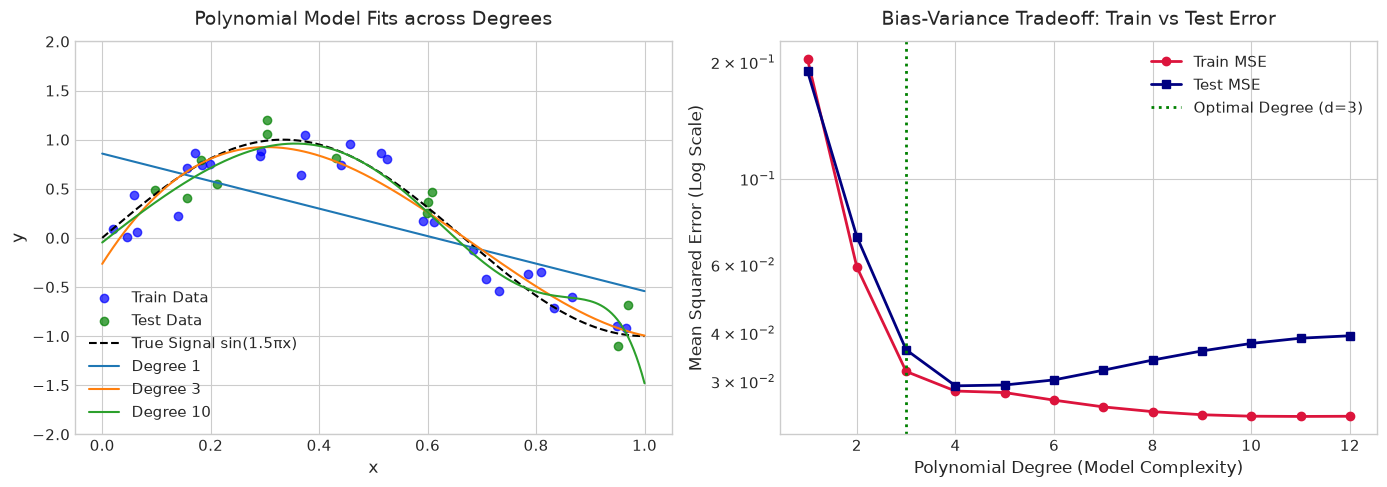

In [18]:
# Generate noisy non-linear dataset
np.random.seed(42)
n_samples = 40
x_data = np.sort(np.random.uniform(0, 1, n_samples))
y_true_func = lambda x: np.sin(1.5 * np.pi * x)
y_data = y_true_func(x_data) + np.random.normal(0, 0.2, n_samples)

# Split into Train (70%) and Test (30%)
x_train_bv, x_test_bv, y_train_bv, y_test_bv = train_test_split(
    x_data, y_data, test_size=0.3, random_state=42
)

degrees = np.arange(1, 13)
train_mses = []
test_mses = []

x_plot = np.linspace(0, 1, 200)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(x_train_bv, y_train_bv, color='blue', alpha=0.7, label='Train Data')
plt.scatter(x_test_bv, y_test_bv, color='green', alpha=0.7, label='Test Data')
plt.plot(x_plot, y_true_func(x_plot), 'k--', label='True Signal sin(1.5πx)')

# Polynomial Fits for Degree 1, 3, 10
for deg in degrees:
    poly_model = make_pipeline(PolynomialFeatures(degree=deg), Ridge(alpha=1e-5))
    poly_model.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    y_train_pred = poly_model.predict(x_train_bv.reshape(-1, 1))
    y_test_pred = poly_model.predict(x_test_bv.reshape(-1, 1))

    train_mses.append(mean_squared_error(y_train_bv, y_train_pred))
    test_mses.append(mean_squared_error(y_test_bv, y_test_pred))

    if deg in [1, 3, 10]:
        plt.plot(x_plot, poly_model.predict(x_plot.reshape(-1, 1)), label=f'Degree {deg}')

plt.ylim(-2, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Model Fits across Degrees', pad=12)
plt.legend(loc='lower left')

# Plot Train MSE vs Test MSE across Degrees
plt.subplot(1, 2, 2)
plt.plot(degrees, train_mses, 'o-', color='crimson', lw=2, label='Train MSE')
plt.plot(degrees, test_mses, 's-', color='navy', lw=2, label='Test MSE')

plt.yscale('log')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.title('Bias-Variance Tradeoff: Train vs Test Error', pad=12)
plt.axvline(x=3, color='green', linestyle=':', lw=2, label='Optimal Degree (d=3)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


---
# 6. Summary & Best Practices Cheat Sheet

### 1. Metric Selection Quick Reference
| Scenario / Task Goal | Recommended Primary Metric | Why? |
|---|---|---|
| Balanced Classification | **Accuracy**, **Macro F1** | Evaluates overall correct predictions across classes. |
| Imbalanced Data (General) | **PR-AUC / Average Precision** | Robust against high True Negative prevalence. |
| High Cost of False Positives (e.g. Spam Detection) | **Precision** | Ensures predicted positives are highly trustworthy. |
| High Cost of False Negatives (e.g. Cancer Diagnosis) | **Recall / Sensitivity** | Captures maximum true positive instances. |
| Tradeoff between Precision and Recall | **F1-Score** | Harmonic mean balancing precision and recall. |

---

### 2. Cross-Validation Guidelines
- **Standard K-Fold ($K=5$ or $10$)**: Default choice for regression or balanced classification datasets.
- **Stratified K-Fold**: **Must-use** for classification tasks with class imbalance.
- **Leave-One-Out (LOOCV)**: Use only for very small datasets ($N < 100$) where data scarcity is critical.

---

### 3. Hyperparameter Search Strategy
1. **GridSearchCV**: Best for searching 1-2 critical hyperparameters over a coarse grid.
2. **RandomizedSearchCV**: Best for initial broad exploration across high-dimensional parameter spaces.
3. **BayesSearchCV**: Best for fine-tuning computationally expensive models (e.g. ensembles, deep learning) where every trial count matters.

---

### 4. Regularization Decision Tree
- Use **Lasso (L1)** when feature selection is desired and you suspect many features are redundant or uninformative.
- Use **Ridge (L2)** when dealing with severe multicollinearity and keeping all features in the model is preferred.
- Use **ElasticNet** when features are correlated and feature selection is needed simultaneously.

---

### End of Module 6
Congratulations! You have mastered model evaluation, cross-validation, hyperparameter tuning, regularization, and bias-variance diagnostics in Python with Scikit-Learn and Scikit-Optimize!
